In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

X_train = pd.read_csv('../data/train_test/X_train.csv')
X_test = pd.read_csv('../data/train_test/X_test.csv')
y_train = pd.read_csv('../data/train_test/y_train.csv').squeeze()
y_test = pd.read_csv('../data/train_test/y_test.csv').squeeze()

In [3]:
# Entraînement du modèle Random Forest
rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
# Encoder les variables catégorielles pour éviter l'erreur "could not convert string to float"
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# Aligner les colonnes train/test
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       584
           1       1.00      1.00      1.00       291

    accuracy                           1.00       875
   macro avg       1.00      1.00      1.00       875
weighted avg       1.00      1.00      1.00       875

ROC-AUC: 1.000


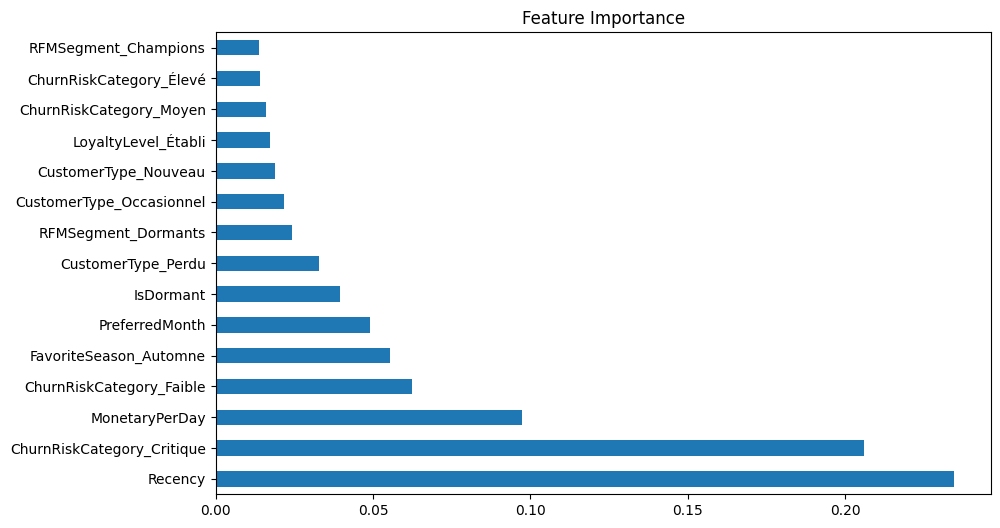

In [ ]:
# Visualisation de l'importance des features
importance = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importance.head(15).plot(kind='barh', figsize=(10,6))
plt.title('Feature Importance')
plt.show()

c:\Users\User\Desktop\MLproject\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


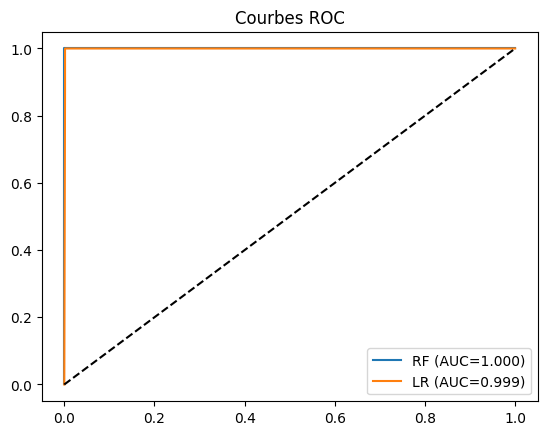

In [5]:
# Entraînement du modèle Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)

for model, name in [(rf, 'RF'), (lr, 'LR')]:
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.legend()
plt.title('Courbes ROC')
plt.show()

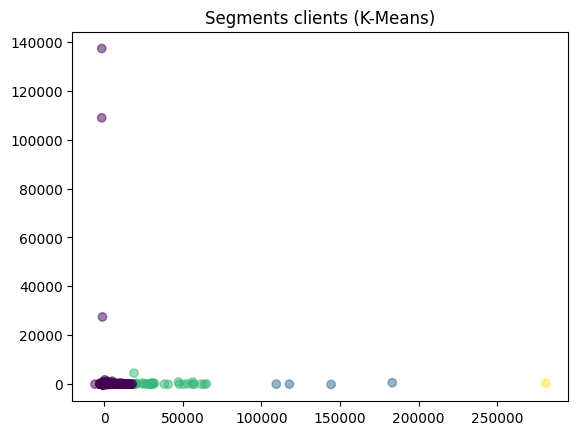

Cluster
0    0.335450
1    0.000000
2    0.035714
3    0.000000
Name: Churn, dtype: float64

In [ ]:
# Segmentation clients avec K-Means
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_train)

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', alpha=0.5)
plt.title('Segments clients (K-Means)')
plt.show()

# Analyse churn par cluster
pd.DataFrame({'Cluster': clusters, 'Churn': y_train}).groupby('Cluster')['Churn'].mean()